In [1]:
%config InteractiveShell.ast_node_interactivity='last_expr_or_assign'  # always print last expr.
%config InlineBackend.figure_format = 'svg'
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
import matplotlib.pyplot as plt
# recommended styles: 'bmh' 'fivethirtyeight' 'ggplot' 'seaborn-darkgrid'
plt.style.use('bmh')
plt.rcParams['axes.axisbelow'] = True

In [3]:
import numpy as np
import pandas
import pandas as pd
from pandas import DataFrame, Index, Series, Timedelta, Timestamp


from tsdm.util.strings import snake2camel

rng = np.random.default_rng()
np.set_printoptions()

## Helper Functions

In [4]:
def update_legend(ax, legend_dict, *, legend_kwargs=None, **kwargs):
    """Update the legend with a dict[line, "name"]. Useful for dynamically updating the legend."""
    _legend_kwargs = dict(
        frameon=False,
        loc="upper right",
        bbox_to_anchor=(0.75, 0.95, 0.05, 0.05),
        mode="expand",
    )
    legend_kwargs = _legend_kwargs.update(
        {} if legend_kwargs is None else legend_kwargs
    )
    for key, val in kwargs.items():
        legend_dict[key] = val
    leg = ax.legend(legend_dict.keys(), legend_dict.values(), **legends_kwargs)

In [5]:
def data_overview(df: DataFrame):
    overview = DataFrame(index=df.columns)
    mask = pandas.isna(df)
    overview["# datapoints"] = (~mask).sum()
    overview["% missing"] = (mask.mean()*100).round(2)
    overview["min"] = df.min().round(2)
    overview["mean"] = df.mean().round(2)
    overview["std"] = df.std().round(2)
    overview["max"] = df.max().round(2)
    overview["unit"] = units[df.columns]
    freq = {}
    for col in df:
        mask = pandas.notna(df[col])
        time = pandas.to_timedelta(df["runtime"][mask], unit="h")
        freq[col] = time.diff().mean()
    overview["freq"] = Series(freq).round("s").dt.to_pytimedelta().astype(str)
    return overview

## Some prep work

In [6]:
from tsdm.datasets import KIWI_RUNS

data = KIWI_RUNS.load("measurements_aggregated")
data = data.rename(columns={col:snake2camel(col) for col in data})

for run_exp in data.reset_index(level=2).index.unique():
    time = data.loc[run_exp].index
    td = (time - time.min()) / Timedelta("1h")
    data.loc[run_exp, "runtime"] = td

data 

Unit   FlowAir  StirringSpeed  \
run_id experiment_id measurement_time                                       
355    11722         2019-04-09 18:32:12      °C      <NA>           <NA>   
                     2019-04-09 18:32:18     NaN      <NA>           <NA>   
                     2019-04-09 18:32:19     NaN      <NA>           <NA>   
                     2019-04-09 18:32:21  Ln/min      <NA>           <NA>   
                     2019-04-09 18:32:21  Ln/min  4.997213           <NA>   
...                                          ...       ...            ...   
510    16871         2021-10-26 22:42:20     NaN      <NA>           <NA>   
                     2021-10-26 22:42:20     NaN      <NA>           <NA>   
                     2021-10-26 22:43:22      °C      <NA>           <NA>   
                     2021-10-26 22:43:31     NaN      <NA>           <NA>   
                     2021-10-26 22:43:31     NaN      <NA>           <NA>   

                                          Temperature  Acetate  Base  \
run_id experiment_id measurement_time                                  
355    11722         2019-04-09 18:32:12    36.990002     <NA>  <NA>   
                     2019-04-09 18:32:18         <NA>     <NA>  <NA>   
                     2019-04-09 18:32:19         <NA>     <NA>  <NA>   
                     2019-04-09 18:32:21         <NA>     <NA>  <NA>   
                     2019-04-09 18:32:21         <NA>     <NA>  <NA>   
...                                               ...      ...   ...   
510    16871         2021-10-26 22:42:20         <NA>     <NA>  <NA>   
                     2021-10-26 22:42:20         <NA>     <NA>  <NA>   
                     2021-10-26 22:43:22    37.439999     <NA>  <NA>   
                     2021-10-26 22:43:31         <NA>     <NA>  <NA>   
                     2021-10-26 22:43:31         <NA>     <NA>  <NA>   

                                          CumulatedFeedVolumeGlucose  \
run_id experiment_id measurement_time                                  
355    11722         2019-04-09 18:32:12                        <NA>   
                     2019-04-09 18:32:18                        <NA>   
                     2019-04-09 18:32:19                        <NA>   
                     2019-04-09 18:32:21                        <NA>   
                     2019-04-09 18:32:21                        <NA>   
...                                                              ...   
510    16871         2021-10-26 22:42:20                        <NA>   
                     2021-10-26 22:42:20                        <NA>   
                     2021-10-26 22:43:22                        <NA>   
                     2021-10-26 22:43:31                        <NA>   
                     2021-10-26 22:43:31                        <NA>   

                                          CumulatedFeedVolumeMedium  \
run_id experiment_id measurement_time                                 
355    11722         2019-04-09 18:32:12                       <NA>   
                     2019-04-09 18:32:18                       <NA>   
                     2019-04-09 18:32:19                       <NA>   
                     2019-04-09 18:32:21                       <NA>   
                     2019-04-09 18:32:21                       <NA>   
...                                                             ...   
510    16871         2021-10-26 22:42:20                       <NA>   
                     2021-10-26 22:42:20                       <NA>   
                     2021-10-26 22:43:22                       <NA>   
                     2021-10-26 22:43:31                       <NA>   
                     2021-10-26 22:43:31                       <NA>   

                                                DOT  Glucose  OD600  \
run_id experiment_id measurement_time                                 
355    11722         2019-04-09 18:32:12       <NA>     <NA>   <NA>   
                     2019-04-09

In [7]:
_units = data["Unit"]
data = data.drop(columns="Unit")
data = data.astype("float32")

units = Series(dtype=pandas.StringDtype())

for col in data:
    if col =="runtime": continue
    mask = pandas.notna(data[col])
    unit = _units[mask].unique().to_list()
    assert len(unit) <= 1, f"{col}, {unit} {len(unit)}"
    units[col] = unit[0]

units["DOT"] = "%"
units["OD600"] = "%"
units["PH"] = "-log[H⁺]"
units["Acetate"] = "g/L"
units["runtime"] = "h"
units = units.fillna(pd.NA).astype("string").astype("category")

FlowAir                         Ln/min
StirringSpeed                    U/min
Temperature                         °C
Acetate                            g/L
Base                                uL
CumulatedFeedVolumeGlucose          uL
CumulatedFeedVolumeMedium           uL
DOT                                  %
Glucose                            g/L
OD600                                %
ProbeVolume                         uL
PH                            -log[H⁺]
FluoGFP                            RFU
InducerConcentration                mM
Volume                              mL
runtime                              h
dtype: category
Categories (11, object): ['%', '-log[H⁺]', 'Ln/min', 'RFU', ..., 'mL', 'mM', 'uL', '°C']

## Overview Raw Data

In [8]:
overview = data_overview(data.reset_index(level=[0,1], drop=True))
with pd.option_context('display.float_format', '{:,.2f}'.format):
    display(overview)

,# datapoints,% missing,min,mean,std,max,unit,freq
FlowAir,20184,97.07,0.00,4.82,0.99,10.00,Ln/min,0:00:00
StirringSpeed,1200,99.83,0.00,906.00,"1,193.55","3,000.00",U/min,0:00:00
Temperature,158088,77.06,32.69,37.30,0.52,41.38,°C,0:00:00
Acetate,3980,99.42,-0.27,0.14,0.14,2.25,g/L,0:00:11
Base,17264,97.49,0.00,"1,172.01","1,125.71","4,070.00",uL,0:00:03
CumulatedFeedVolumeGlucose,12655,98.16,3.00,580.55,597.18,"4,101.00",uL,0:00:04
CumulatedFeedVolumeMedium,10911,98.42,5.88,974.02,984.26,"5,060.85",uL,0:00:04
DOT,196129,71.54,0.00,72.82,37.82,498.16,%,0:00:00
Glucose,3897,99.43,-0.12,1.50,2.35,41.09,g/L,0:00:12
OD600,4080,99.41,-1.56,9.17,11.24,221.90,%,0:00:12


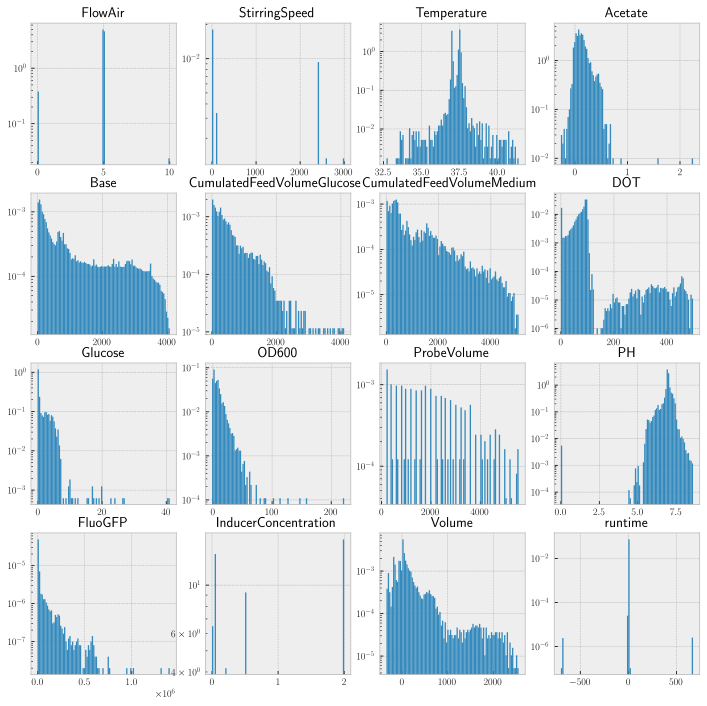

In [9]:
fig, axes = plt.subplots(ncols=4, nrows=4, figsize=(12, 12))
data["runtime"] = data["runtime"].diff()
for col, ax in zip(data, axes.flatten()):
    vals = data[col]
    mask = pandas.notna(vals)
    ax.hist(vals[mask], bins=100, density=True);
    ax.set_title(col)
    # ax.set_xscale("symlog")
    ax.set_yscale("log")

In [10]:
for col in ["OD600", "DOT", "Acetate", "Glucose"]:
    print(data[col][data[col]<0])

run_id  experiment_id  measurement_time   
355     11722          2019-04-10 07:28:04   -1.5625
        11724          2019-04-10 07:28:04   -0.5625
        11727          2019-04-10 07:28:04   -1.1625
                       2019-04-10 07:28:04   -0.7625
        11729          2019-04-10 07:28:04   -0.1625
                                               ...  
439     15346          2020-12-09 22:53:58   -0.0375
        15347          2020-12-09 22:53:58   -0.0375
        15348          2020-12-09 13:48:50   -0.0125
                       2020-12-09 13:48:50   -0.0525
                       2020-12-09 22:53:58   -0.0375
Name: OD600, Length: 65, dtype: float32
Series([], Name: DOT, dtype: float32)
run_id  experiment_id  measurement_time   
355     11722          2019-04-09 19:59:40   -0.003984
                       2019-04-09 23:00:54   -0.008745
                       2019-04-09 23:00:54   -0.019281
                       2019-04-10 00:02:13   -0.021980
                       2019-04-10

## Overview cleaned data

In [11]:
from tsdm.datasets import KIWI_RUNS
data = KIWI_RUNS.dataset
data = data.rename(columns={col:snake2camel(col) for col in data})

FlowAir  StirringSpeed  \
run_id experiment_id measurement_time                               
355    11722         2019-04-09 18:32:12       0.0            0.0   
                     2019-04-09 18:32:18       0.0            0.0   
                     2019-04-09 18:32:19       0.0            0.0   
                     2019-04-09 18:32:21  4.997213            0.0   
                     2019-04-09 18:32:22  4.997213            0.0   
...                                            ...            ...   
510    16871         2021-10-26 22:41:26       5.0            0.0   
                     2021-10-26 22:42:11       5.0            0.0   
                     2021-10-26 22:42:20       5.0            0.0   
                     2021-10-26 22:43:22       5.0            0.0   
                     2021-10-26 22:43:31       5.0            0.0   

                                          Temperature  Acetate  Base  \
run_id experiment_id measurement_time                                  
355    11722         2019-04-09 18:32:12    36.990002     <NA>  <NA>   
                     2019-04-09 18:32:18         <NA>     <NA>  <NA>   
                     2019-04-09 18:32:19         <NA>     <NA>  <NA>   
                     2019-04-09 18:32:21         <NA>     <NA>  <NA>   
                     2019-04-09 18:32:22        36.98     <NA>  <NA>   
...                                               ...      ...   ...   
510    16871         2021-10-26 22:41:26         <NA>     <NA>  <NA>   
                     2021-10-26 22:42:11    37.450001     <NA>  <NA>   
                     2021-10-26 22:42:20         <NA>     <NA>  <NA>   
                     2021-10-26 22:43:22    37.439999     <NA>  <NA>   
                     2021-10-26 22:43:31         <NA>     <NA>  <NA>   

                                          CumulatedFeedVolumeGlucose  \
run_id experiment_id measurement_time                                  
355    11722         2019-04-09 18:32:12                         0.0   
                     2019-04-09 18:32:18                         0.0   
                     2019-04-09 18:32:19                         0.0   
                     2019-04-09 18:32:21                         0.0   
                     2019-04-09 18:32:22                         0.0   
...                                                              ...   
510    16871         2021-10-26 22:41:26                      1061.0   
                     2021-10-26 22:42:11                      1061.0   
                     2021-10-26 22:42:20                      1061.0   
                     2021-10-26 22:43:22                      1061.0   
                     2021-10-26 22:43:31                      1061.0   

                                          CumulatedFeedVolumeMedium  \
run_id experiment_id measurement_time                                 
355    11722         2019-04-09 18:32:12                        0.0   
                     2019-04-09 18:32:18                        0.0   
                     2019-04-09 18:32:19                        0.0   
                     2019-04-09 18:32:21                        0.0   
                     2019-04-09 18:32:22                        0.0   
...                                                             ...   
510    16871         2021-10-26 22:41:26                3787.307373   
                     2021-10-26 22:42:11                3787.307373   
                     2021-10-26 22:42:20                3787.307373   
                     2021-10-26 22:43:22                3787.307373   
                     2021-10-26 22:43:31                3787.307373   

                                                DOT  Glucose  OD600  \
run_id experiment_id measurement_time                                 
355    11722         2019-04-09 18:32:12       <NA>     <NA>   <NA>   
                     2019-04-09 18:32:18  89.660004     <NA>   <NA>   
                     2019-04-09 18:32:19       <NA>     <NA>   

In [12]:
for run_exp in data.reset_index(level=2).index.unique():
    time = data.loc[run_exp].index
    td = (time - time.min()) / Timedelta("1h")
    data.loc[run_exp, "runtime"] = td

overview = data_overview(data.reset_index(level=[0,1], drop=True))
with pd.option_context('display.float_format', '{:,.2f}'.format):
    display(overview)

,# datapoints,% missing,min,mean,std,max,unit,freq
FlowAir,441907,0.00,0.00,5.52,1.69,10.00,Ln/min,0:00:00
StirringSpeed,441907,0.00,0.00,693.72,956.76,"2,600.00",U/min,0:00:00
Temperature,156960,64.48,32.69,37.30,0.52,41.38,°C,0:00:00
Acetate,1891,99.57,0.00,0.14,0.12,1.18,g/L,0:00:24
Base,17264,96.09,0.00,"1,172.00","1,125.71","4,070.00",uL,0:00:03
CumulatedFeedVolumeGlucose,441907,0.00,0.00,397.87,543.72,"4,101.00",uL,0:00:00
CumulatedFeedVolumeMedium,441907,0.00,0.00,"1,053.13","1,044.66","5,060.85",uL,0:00:00
DOT,195469,55.77,0.00,71.15,29.65,100.00,%,0:00:00
Glucose,1823,99.59,0.00,1.50,2.30,40.72,g/L,0:00:25
OD600,1819,99.59,0.01,9.22,9.38,127.88,%,0:00:26


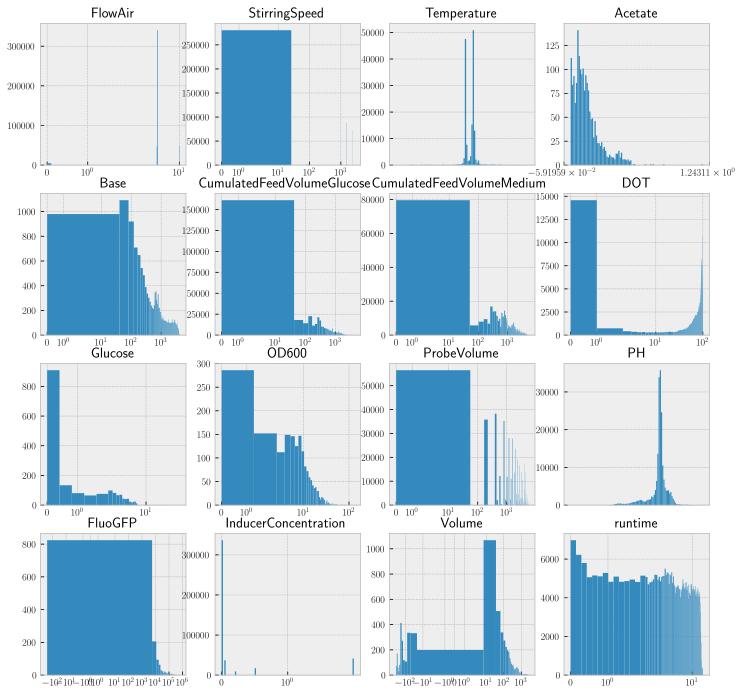

In [13]:
fig, axes = plt.subplots(ncols=4, nrows=4, figsize=(12, 12))

for col, ax in zip(data, axes.flatten()):
    vals = data[col]
    mask = pandas.notna(vals)
    ax.hist(vals[mask], bins=100);
    ax.set_title(col)
    ax.set_xscale("symlog")
    # ax.set_yscale("log")

## Overview Task data

pretty much the same as cleaned but without run 355

In [14]:
from tsdm.tasks import KIWI_RUNS_TASK

data = KIWI_RUNS_TASK().timeseries
data = data.rename(columns={col:snake2camel(col) for col in data})
for run_exp in data.reset_index(level=2).index.unique():
    time = data.loc[run_exp].index
    td = (time - time.min()) / Timedelta("1h")
    data.loc[run_exp, "runtime"] = td

overview = data_overview(data.reset_index(level=[0,1], drop=True))
with pd.option_context('display.float_format', '{:,.2f}'.format):
    display(overview)

,# datapoints,% missing,min,mean,std,max,unit,freq
FlowAir,325952,0.00,0.00,5.71,1.92,10.00,Ln/min,0:00:00
StirringSpeed,325952,0.00,0.00,536.21,999.76,"2,600.00",U/min,0:00:00
Temperature,126744,61.12,32.69,37.33,0.55,41.38,°C,0:00:00
Acetate,1677,99.49,0.00,0.13,0.10,1.18,g/L,0:00:27
Base,6835,97.90,5.00,324.06,330.43,"2,365.00",uL,0:00:04
CumulatedFeedVolumeGlucose,325952,0.00,0.00,320.77,514.23,"4,101.00",uL,0:00:00
CumulatedFeedVolumeMedium,325952,0.00,0.00,"1,253.02","1,134.23","5,060.85",uL,0:00:00
DOT,161437,50.47,0.00,73.14,28.32,100.00,%,0:00:00
Glucose,1604,99.51,0.00,1.62,2.39,40.72,g/L,0:00:28
OD600,1532,99.53,0.01,7.67,7.31,70.22,%,0:00:29


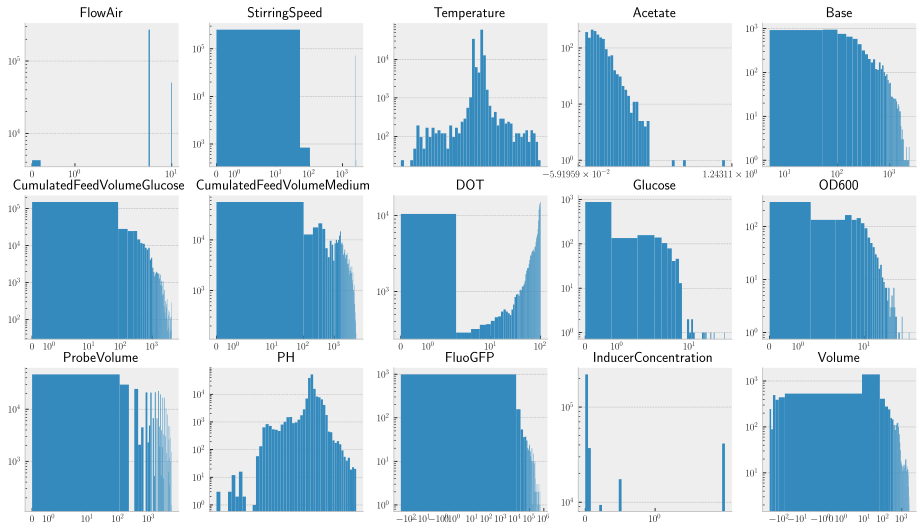

In [15]:

fig, axes = plt.subplots(ncols=5, nrows=3, figsize=(16, 9))

for col, ax in zip(data, axes.flatten()):
    vals = data[col]
    mask = pandas.notna(vals)
    ax.hist(vals[mask], bins=50);
    ax.set_title(col)
    ax.set_xscale("symlog")
    ax.set_yscale("log")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="x")